## 1. Perkenalan Dataset

Dataset yang digunakan adalah **E-Commerce Shipping Dataset** yang berisi informasi pengiriman barang dari sebuah perusahaan e-commerce. Dataset ini saya dapat dari [Kaggle](https://www.kaggle.com/datasets/prachi13/customer-analytics).

**Tujuan**: Memprediksi apakah sebuah paket akan terlambat sampai ke pelanggan.

## 2. Import Library

In [1]:
%pip install pandas seaborn matplotlib scikit-learn plotly tensorflow --quiet

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100



## 3. Memuat Dataset

In [3]:
df = pd.read_csv('../dataset_raw.csv')  

In [4]:
df.head(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [6]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

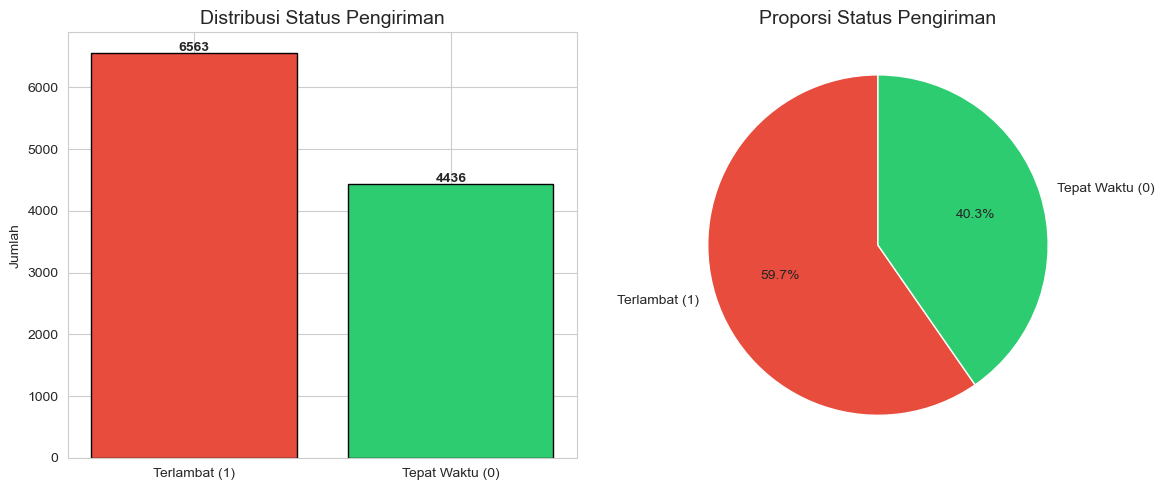

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['Reached.on.Time_Y.N'].value_counts()
labels = ['Terlambat (1)', 'Tepat Waktu (0)']

axes[0].bar(labels, target_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Status Pengiriman', fontsize=14)
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporsi Status Pengiriman', fontsize=14)

plt.tight_layout()
plt.show()

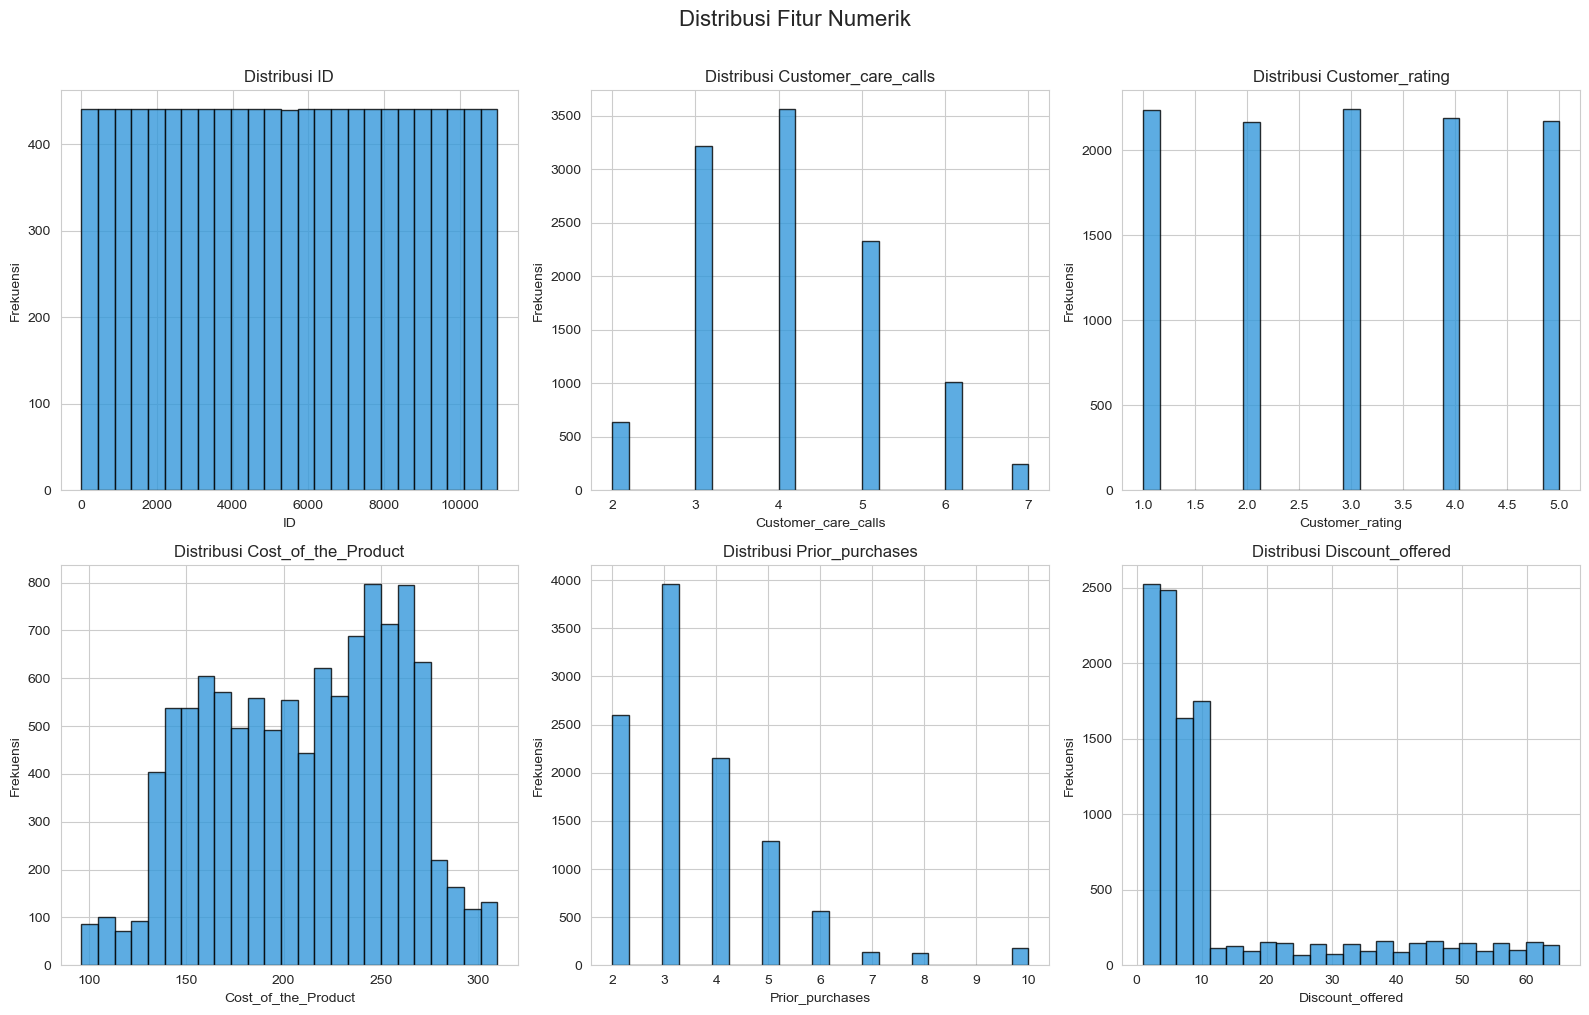

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Reached.on.Time_Y.N', errors='ignore')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i >= len(axes):
        break
    axes[i].hist(df[col], bins=25, edgecolor='black', color='#3498db', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Kolom kategorikal: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


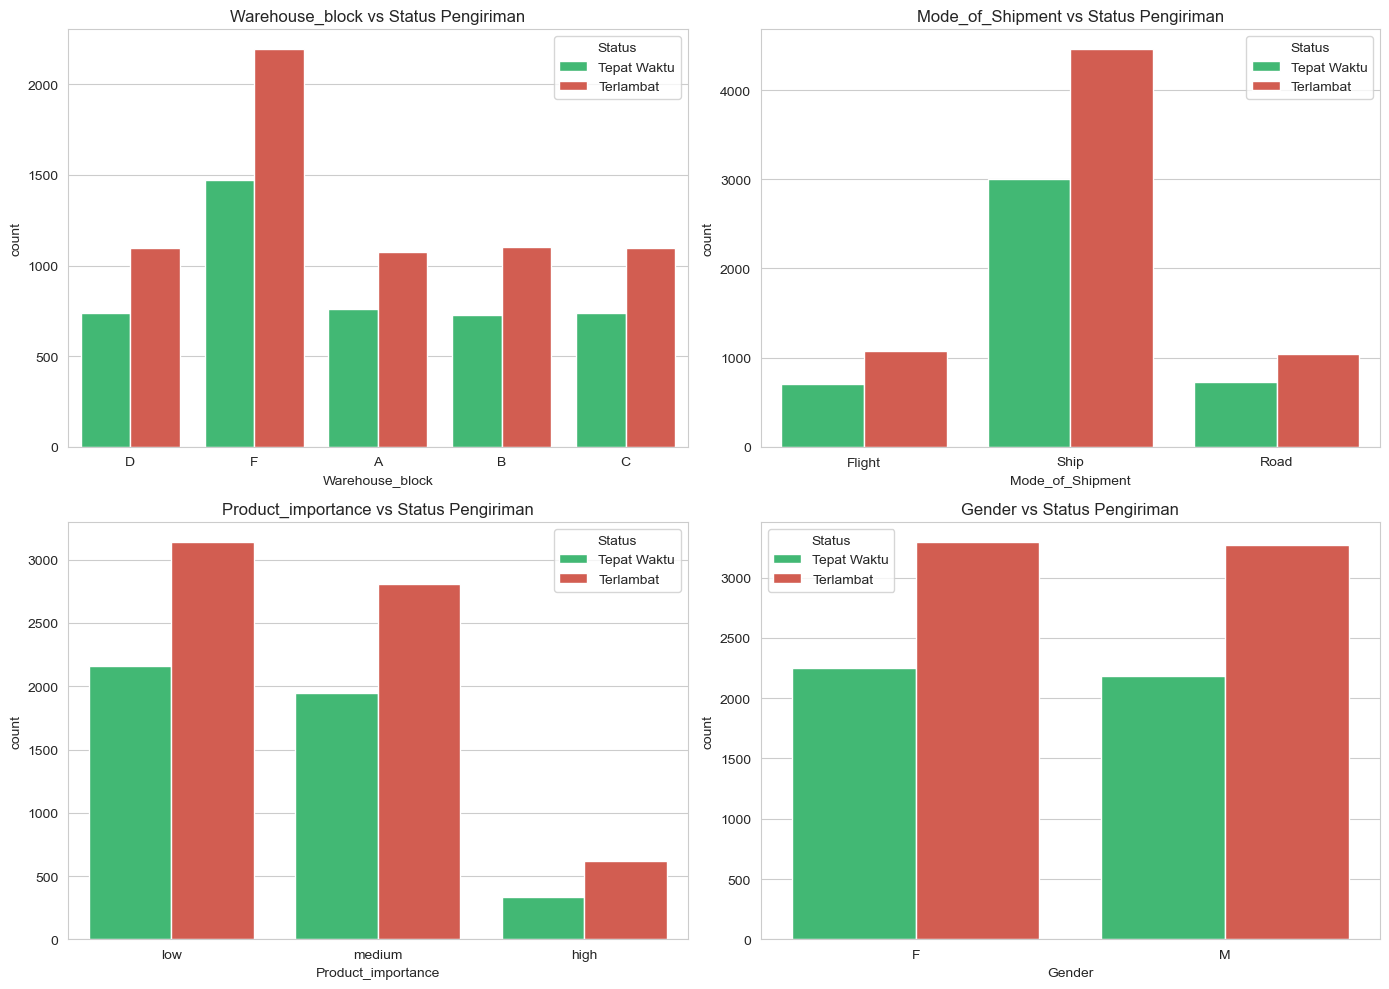

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal: {cat_cols}')

n_cats = len(cat_cols)
n_cols = 2
n_rows = (n_cats + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Reached.on.Time_Y.N',
                  palette=['#2ecc71', '#e74c3c'], ax=axes[i]) 
    axes[i].set_title(f'{col} vs Status Pengiriman', fontsize=12)
    axes[i].legend(title='Status', labels=['Tepat Waktu', 'Terlambat'])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

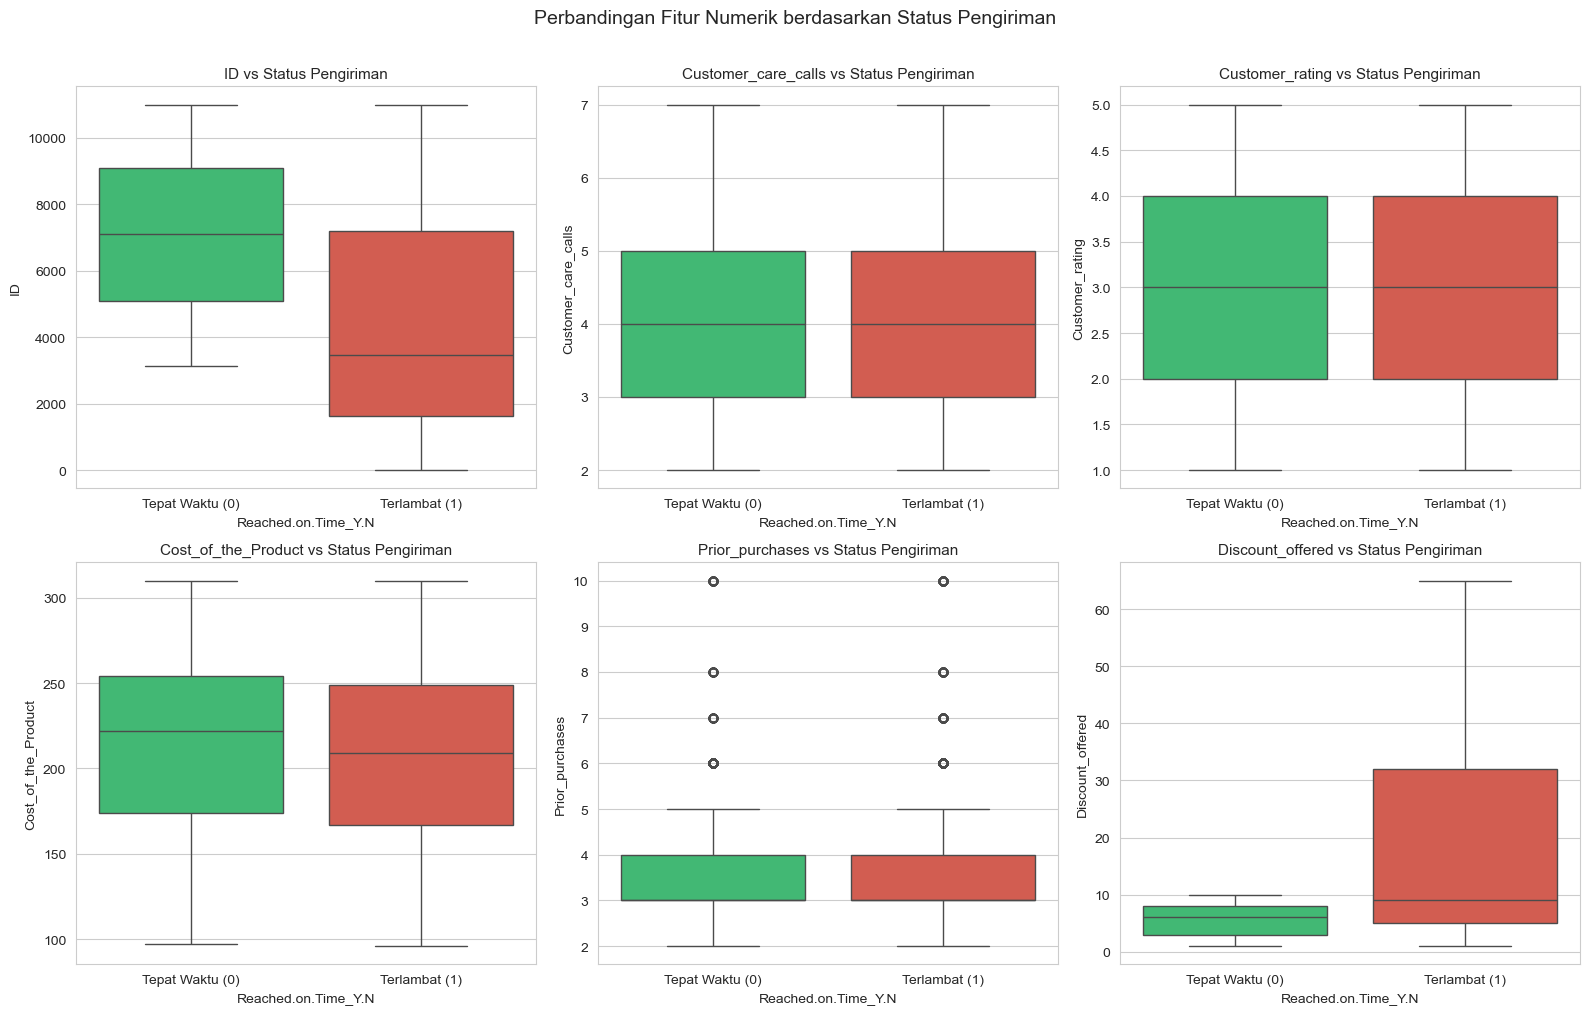

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i >= len(axes):
        break
    sns.boxplot(
        data=df, x='Reached.on.Time_Y.N', y=col,
        palette=['#2ecc71', '#e74c3c'], 
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Status Pengiriman', fontsize=11)
    axes[i].set_xticklabels(['Tepat Waktu (0)', 'Terlambat (1)'])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Perbandingan Fitur Numerik berdasarkan Status Pengiriman', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

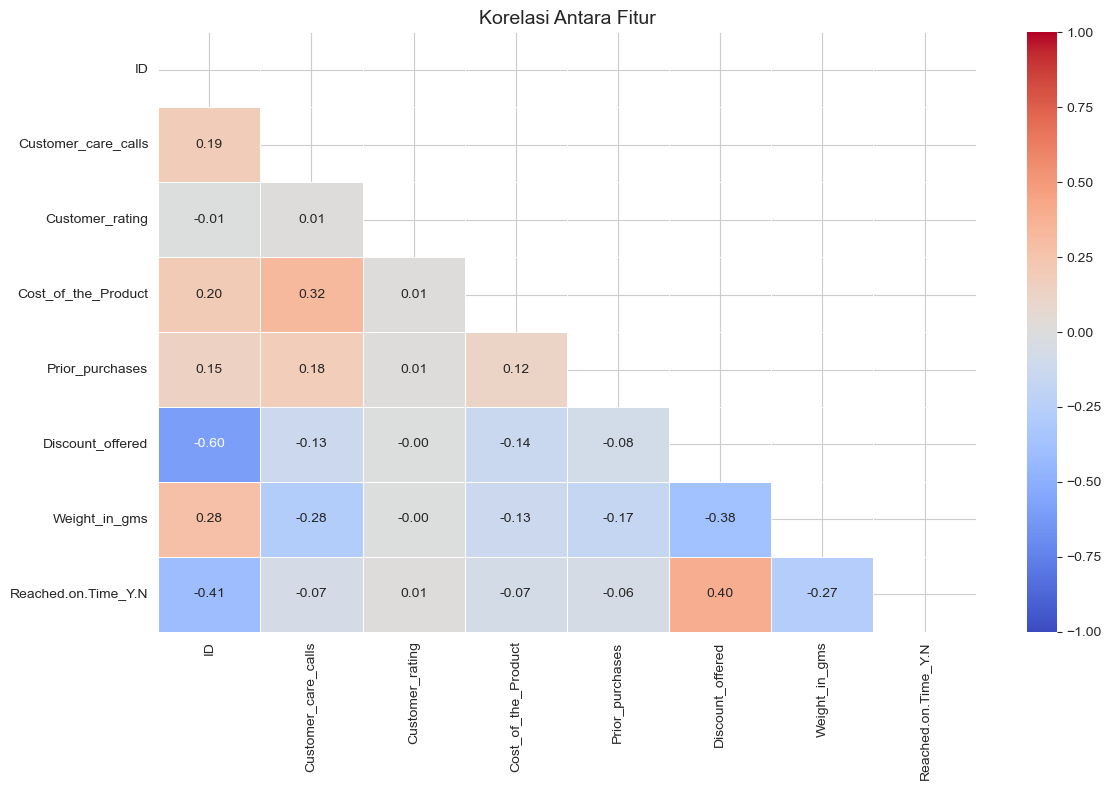

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Korelasi Antara Fitur', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

Tahapan preprocessing:
1. Menghapus kolom yang tidak relevan (`ID`, `Gender`)
2. Mengecek missing values dan duplikasi
3. Menangani outlier pada `Discount_offered`
4. Encoding fitur ordinal (`Product_importance`) dan nominal (`Mode_of_Shipment`, `Warehouse_block`)
5. Train-test split
6. Standarisasi fitur numerik hanya pada training set  dan transform pada test set

In [12]:
df_clean = df.drop(columns=['ID', 'Gender'])

In [13]:
df_clean.isnull().sum()

Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [14]:
q_limit = df_clean['Discount_offered'].quantile(0.95)
df_clean['Discount_offered'] = df_clean['Discount_offered'].clip(upper=q_limit)

In [15]:
# ordinal encoding kolom Product_importance Low=1, Medium=2, High=3
importance_mapping = {'low': 1, 'medium': 2, 'high': 3}
df_clean['Product_importance'] = df_clean['Product_importance'].str.lower().map(importance_mapping)

# One-hot encoding Mode_of_Shipment dan Warehouse_block
df_encoded = pd.get_dummies(df_clean, columns=['Mode_of_Shipment', 'Warehouse_block'], drop_first=False)

# Mengubah kolom boolean ke int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Kolom: {df_encoded.columns.tolist()}')

Kolom: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N', 'Mode_of_Shipment_Flight', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Warehouse_block_A', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F']


In [16]:
X = df_encoded.drop(columns=['Reached.on.Time_Y.N'])
y = df_encoded['Reached.on.Time_Y.N']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #
)

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')

Training set: (8799, 15)
Testing set:  (2200, 15)


In [18]:

cols_to_scale = ['Customer_care_calls', 'Cost_of_the_Product',
                 'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
                 'Customer_rating', 'Product_importance']

cols_to_scale = [c for c in cols_to_scale if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])  

In [19]:
X_train.head(5)

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F
7920,-0.043121,-1.415468,1.056631,-1.032208,0.609537,-0.266189,0.322365,0,1,0,0,0,0,1,0
1529,-0.921405,0.001852,-1.003783,-1.032208,-0.946852,0.840740,-1.206929,0,0,1,0,0,0,0,1
10521,-0.921405,-0.706808,0.224140,-1.032208,0.609537,-0.266189,0.510849,0,0,1,0,1,0,0,0
9558,-0.921405,1.419173,-1.107845,0.272734,0.609537,-0.721983,0.617330,0,0,1,0,0,0,1,0
968,-1.799688,1.419173,1.285566,-1.032208,-0.946852,0.710513,0.004144,1,0,0,1,0,0,0,0
